**You can download the dataset from Kaggle at this link: [Credit Card Fraud Detection Dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).**

---

### 📊 Dataset Overview

- **Source**: Published by the Machine Learning Group (MLG) at Université Libre de Bruxelles (ULB) in collaboration with Worldline.
- **Timeframe**: Transactions from European cardholders over two days in September 2013.
- **Size**: 284,807 transactions, including 492 labeled as fraudulent.
- **Class Imbalance**: Only **0.172%** of transactions are frauds — ideal for testing anomaly detection models.
- **Features**:
  - **V1–V28**: Principal components from PCA (original features anonymized).
  - **Time**: Seconds since the first transaction.
  - **Amount**: Transaction value.
  - **Class**: Target label (1 = fraud, 0 = genuine).

---

### 📥 How to Download

1. Go to the [Kaggle dataset page](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).
2. Sign in or create a Kaggle account.
3. Click “Download” to get the `creditcard.csv` file.

You can place the file in your project’s `data/raw_data/` folder as `creditcard.csv` to match your template.

---

### 🧠 Modeling Tips

- **Use AUPRC (Area Under Precision-Recall Curve)** for evaluation due to extreme class imbalance.
- Consider techniques like:
  - **Undersampling** or **SMOTE** for balancing.
  - **Isolation Forest**, **Autoencoders**, or **XGBoost** for anomaly detection.
  - **Cost-sensitive learning** using the `Amount` feature.


## **2. Exploratory Data Analysis**

In [83]:
import numpy as np              # Imports NumPy for numerical operations and array handling
import pandas as pd            # Imports pandas for data manipulation and analysis using DataFrames
import matplotlib.pyplot as plt  # Imports matplotlib for creating static visualizations and plots
import seaborn as sns          # Imports seaborn for advanced statistical visualizations built on top of matplotlib
import pickle                  # Imports pickle for saving and loading Python objects (e.g., trained models)
import os                      # Imports os for interacting with the operating system (e.g., file paths, directories)


In [84]:
df = pd.read_csv('C:\\Users\\men_l\\Downloads\\End-to-End-Fraud-Detection-Project\\data\\raw_data\\creditcard.csv')  # Loads the credit card fraud dataset from the specified CSV file into a pandas DataFrame
# df = pd.read_csv(r'C:\Users\men_l\Downloads\End-to-End-Fraud-Detection-Project\data\raw_data\creditcard.csv')  # 'r' makes it a raw string, so backslashes are treated literally



In [85]:
df.head()  # Displays the first 5 rows of the DataFrame to preview the dataset structure and contents


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.00,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,...,-0.02,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,149.62,0
1,0.00,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,...,-0.23,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,2.69,0
2,1.00,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,...,0.25,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,378.66,0
3,1.00,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,...,-0.11,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,123.50,0
4,2.00,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,...,-0.01,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,69.99,0


In [86]:
df.info()  # Displays a concise summary of the DataFrame: column names, non-null counts, data types, and memory usage


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [87]:
# Print the shape of the DataFrame: (number of rows, number of columns)
print(df.shape)

# Show the unique values in the 'class' column to confirm the binary classification labels (0 = non-fraud, 1 = fraud)
print(df['Class'].unique())

# Count the number of non-fraudulent transactions (where Class == 0)
print((df.Class == 0).sum())

# Count the number of fraudulent transactions (where Class == 1)
print((df.Class == 1).sum())


(284807, 31)
[0 1]
284315
492


<Axes: xlabel='Class', ylabel='count'>

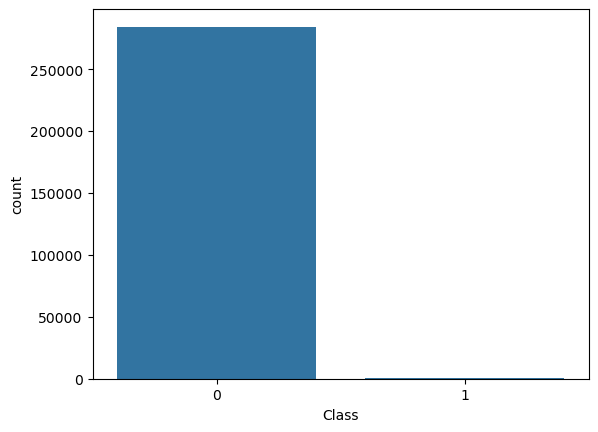

In [88]:
# Create a bar plot showing the count of each class (0 = non-fraud, 1 = fraud) to visualize class imbalance
sns.countplot(x='Class', data=df)


⚠️ **Credit card fraud datasets**, including this one, are typically highly imbalanced because occurrences of fraud are rare compared to normal transactions.  
In the next sections, we will explore effective strategies for handling this imbalance.


## **3. Feature Selection**

In [89]:
# Compute the correlation matrix for all features in the DataFrame
# Then extract the correlation values between each feature and the 'Class' column (target variable)
x = df.corr()['Class'][:30]

# Display the correlation values for the first 30 features with respect to 'Class'
x


Time     -0.01
V1       -0.10
V2        0.09
V3       -0.19
V4        0.13
V5       -0.09
V6       -0.04
V7       -0.19
V8        0.02
V9       -0.10
V10      -0.22
V11       0.15
V12      -0.26
V13      -0.00
V14      -0.30
V15      -0.00
V16      -0.20
V17      -0.33
V18      -0.11
V19       0.03
V20       0.02
V21       0.04
V22       0.00
V23      -0.00
V24      -0.01
V25       0.00
V26       0.00
V27       0.02
V28       0.01
Amount    0.01
Name: Class, dtype: float64

<Axes: title={'center': 'Correlation of Features with Target Variable'}>

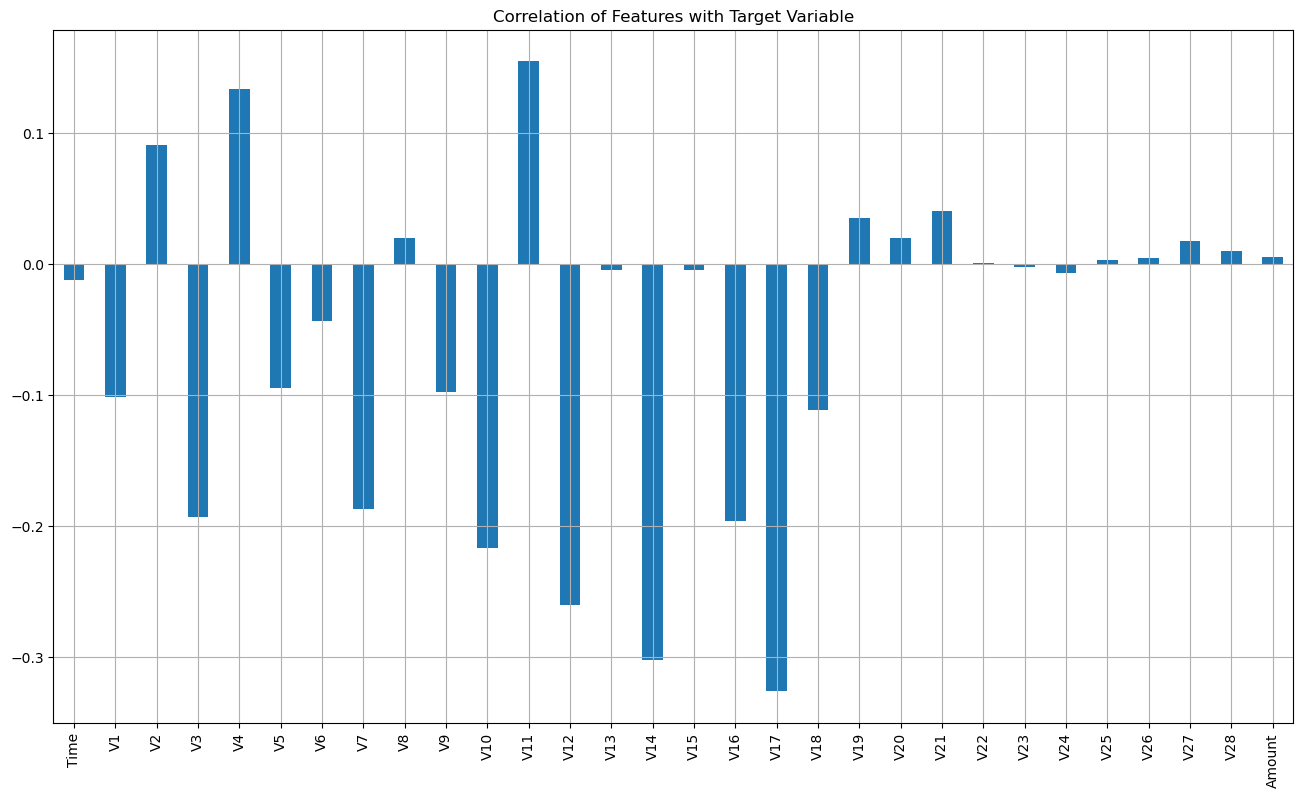

In [90]:
# Compute the correlation between all features and the target variable 'Class'
correlations = df.corr()['Class'][:30]  # Select the first 30 features (excluding 'Class' itself)

# Plot the correlations as a bar chart to visualize which features are most associated with fraud
correlations.plot.bar(
    figsize=(16, 9),  # Set the figure size for better readability
    title="Correlation of Features with Target Variable",  # Add a descriptive title
    grid=True  # Enable grid lines for easier interpretation
)


📌 Some features exhibit a negligible correlation with the target variable and will be removed in the subsequent sections.  
First, we'll examine the intercorrelation among variables.


<Axes: >

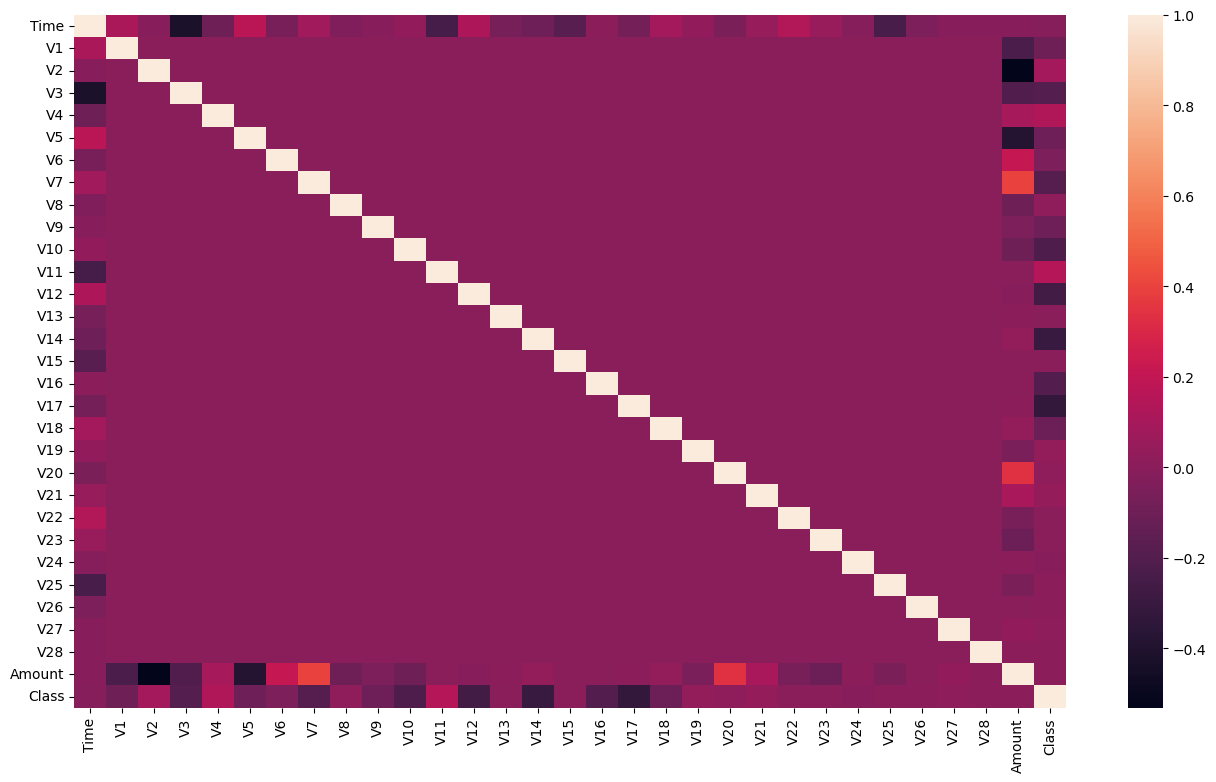

In [91]:
# Set the size of the figure to 16x9 inches for better readability
plt.figure(figsize=(16, 9))

# Create a heatmap to visualize the correlation matrix of all features in the DataFrame
sns.heatmap(df.corr())


📌 The only intercorrelated variable among others is the transaction **Amount**.  
However, this variable shows **no correlation** with the target variable, so it will also be removed.


In [92]:
# Compute the correlation between each feature and the target variable 'Class'
y = df.corr()['Class']

# Create a copy of the original DataFrame to preserve the raw data
df2 = df.copy()

# Loop through all columns in the original DataFrame
for i in df.columns:
    # If the absolute correlation with 'Class' is less than 0.13 (weak relationship),
    # drop the column from the copied DataFrame
    if abs(y[i]) < 0.13:
        df2.drop(columns=[i], inplace=True)


📌 Here, we filter our dataset to keep only features with a correlation above **0.13**.


In [93]:
# Display the first 5 rows of the filtered DataFrame (df2) to preview the retained features after correlation-based selection
df2.head()


,V3,V4,V7,V10,V11,V12,V14,V16,V17,Class
0,2.54,1.38,0.24,0.09,-0.55,-0.62,-0.31,-0.47,0.21,0
1,0.17,0.45,-0.08,-0.17,1.61,1.07,-0.14,0.46,-0.11,0
2,1.77,0.38,0.79,0.21,0.62,0.07,-0.17,-2.89,1.11,0
3,1.79,-0.86,0.24,-0.05,-0.23,0.18,-0.29,-1.06,-0.68,0
4,1.55,0.40,0.59,0.75,-0.82,0.54,-1.12,-0.45,-0.24,0


<Axes: >

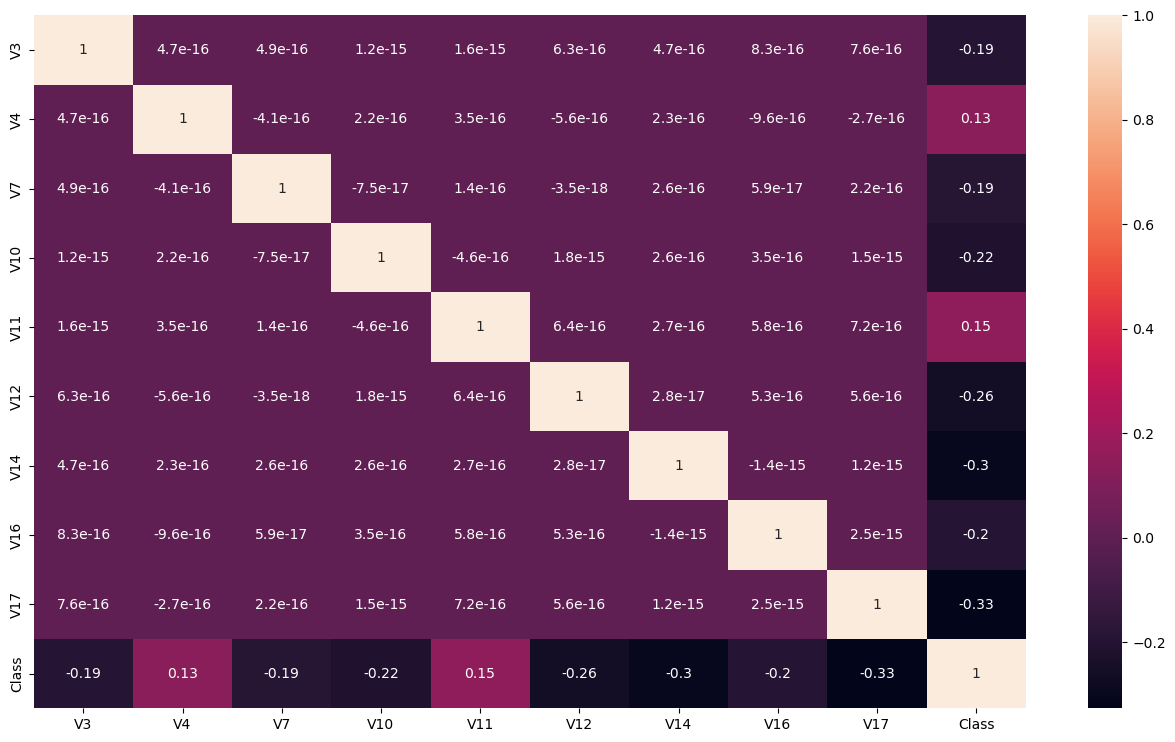

In [94]:
# Set the figure size to 16x9 inches for a large, readable heatmap
plt.figure(figsize=(16, 9))

# Generate a heatmap of the correlation matrix for the filtered DataFrame (df2)
# 'annot=True' displays the correlation values inside each cell
sns.heatmap(df2.corr(), annot=True)


<Axes: title={'center': 'Top Correlated Features With The Target Variable'}>

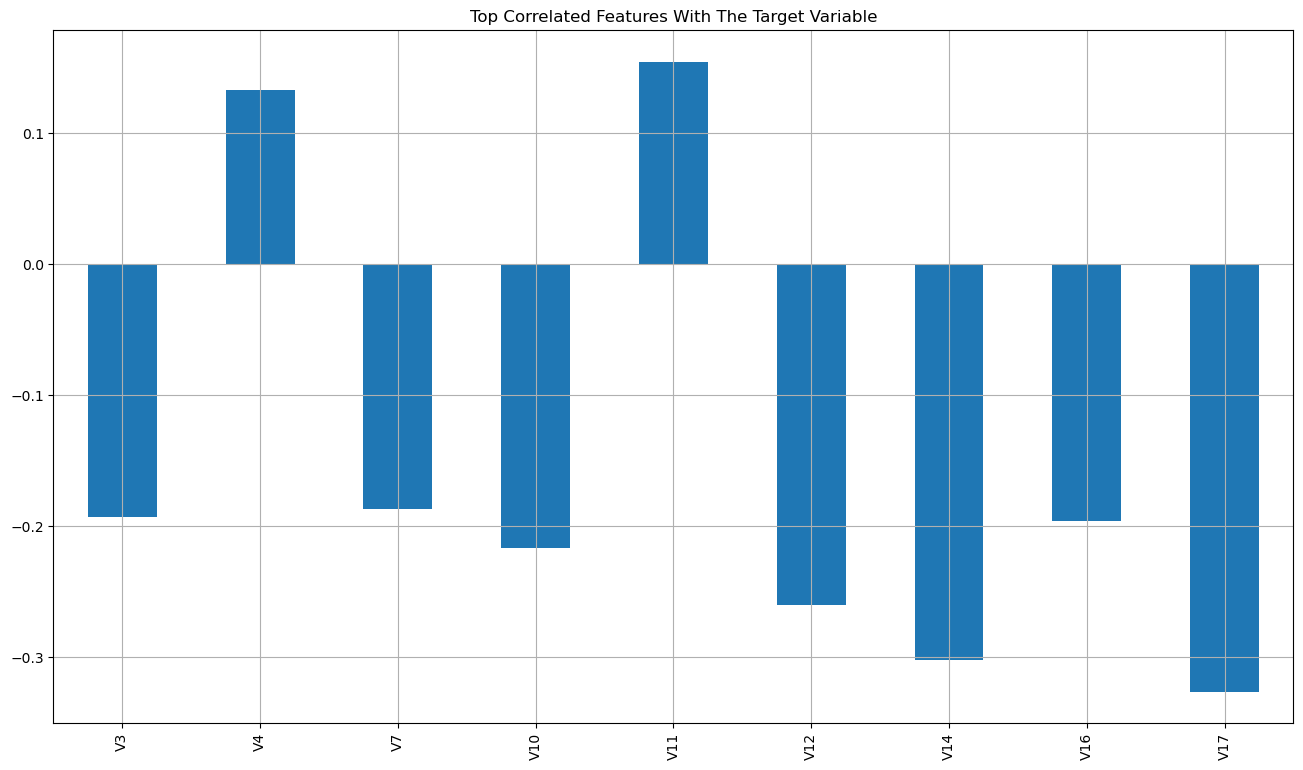

In [95]:
# Select the top 9 features most correlated with the target variable 'Class'
x = df2.corr()['Class'][:9]

# Plot a bar chart to visualize the strength of correlation between these features and the target
x.plot.bar(
    figsize=(16, 9),  # Set figure size for readability
    title="Top Correlated Features With The Target Variable",  # Add a descriptive title
    grid=True  # Enable grid lines for easier interpretation
)


### 4. Handling Data Imbalance

This dataset consists of:

- **Class 0 (non-fraudulent transactions)**: 284,315 records  
- **Class 1 (fraudulent transactions)**: 492 records  

Using this dataset as-is would be a **fatal mistake** due to its severe class imbalance. Here's why:

---

#### ⚠️ Using the Data As-Is

- The overwhelming majority of records belong to the non-fraudulent class (Class 0), making up **over 99%** of the dataset.
- Models trained on imbalanced data may prioritize accuracy on the majority class while neglecting the minority class (fraudulent transactions).
- This can result in **poor performance** in detecting fraud.

---

#### ❌ Why Oversampling Can Be Risky

- Techniques like **SMOTE** (Synthetic Minority Over-sampling Technique) artificially inflate the minority class by generating synthetic examples.
- This can lead to **overfitting** and the introduction of **noise**, especially when the minority class is already sparse.

---

#### ✅ Why Downsampling Is Preferred

- Downsampling randomly reduces the number of samples in the majority class to balance it with the minority class.
- This helps mitigate bias toward the majority class while maintaining dataset integrity.
- By equalizing class sizes, the model learns from both classes more effectively, improving fraud detection.

---

#### 📊 Using Imbalanced Data (No Sampling)

**Dataset:**
- Class 0: 284,315 records  
- Class 1: 492 records  

**Example Performance:**
- Accuracy: **99.8%**

**Confusion Matrix:**

|                          | Predicted Non-Fraudulent | Predicted Fraudulent |
|--------------------------|--------------------------|----------------------|
| Actual Non-Fraudulent    | 71,078                   | 200                  |
| Actual Fraudulent        | 50                       | 40                   |

**Issue:** High accuracy is misleading; the model fails to detect most fraudulent transactions (**low recall for Class 1**).

---

#### 📊 Oversampling (SMOTE) Example

**Dataset After SMOTE:**
- Class 0: 284,315 records  
- Class 1: 284,315 synthetic records  

**Example Performance:**
- Accuracy: **98.5%**

**Confusion Matrix:**

|                          | Predicted Non-Fraudulent | Predicted Fraudulent |
|--------------------------|--------------------------|----------------------|
| Actual Non-Fraudulent    | 70,800                   | 478                  |
| Actual Fraudulent        | 10                       | 80                   |

**Issue:** High accuracy but **high false positives** due to synthetic examples, leading to **overfitting** and reduced **precision** for fraud detection.


⚠️ **Please note that we are discussing the training data, not the test data.**  
The test data should represent **"reality."** If the data the model will encounter in real life is imbalanced, then the model should be tested on imbalanced data.

However, as explained earlier, to avoid bias in learning, the model should be **trained on balanced data**.


📌 Having recognized why **downsampling** is the optimal technique for this dataset, let's proceed with downsampling our dataset.

We will downsample the **entire dataset** initially to study outliers.  
Later, we will perform a proper **split of the training and test data**.

- The **training data** will be downsampled and balanced to avoid bias during learning.
- The **test data** will reflect the original imbalanced distribution to evaluate the model in a realistic scenario.


In [96]:
from imblearn.under_sampling import RandomUnderSampler

# Separate the feature matrix (X) and target vector (y)
X = df2.drop('Class', axis=1)  # Drop the target column to isolate features
y = df2['Class']  # Extract the target column

# Initialize the RandomUnderSampler with a fixed random state for reproducibility
rus = RandomUnderSampler(random_state=42)

# Apply undersampling to balance the dataset by reducing majority class samples
X_resampled, y_resampled = rus.fit_resample(X, y)

# Reconstruct a DataFrame from the resampled features and target
downsampled_df = pd.concat(
    [pd.DataFrame(X_resampled, columns=X.columns), pd.DataFrame(y_resampled, columns=['Class'])],
    axis=1
)

# Preview the first few rows of the downsampled dataset
downsampled_df.head()


,V3,V4,V7,V10,V11,V12,V14,V16,V17,Class
138028,-0.67,0.72,0.39,-0.60,-0.33,-0.22,-1.05,0.60,0.63,0
63099,0.90,0.69,0.50,0.17,0.82,0.47,0.57,-0.01,-0.50,0
73411,1.12,-1.31,-0.70,2.05,0.58,-0.59,-0.34,-0.76,0.54,0
164247,-0.99,-0.03,0.78,-1.24,-0.84,-0.59,-0.44,0.27,0.70,0
148999,0.27,3.87,-0.72,1.17,1.30,-1.92,1.32,1.32,-0.44,0


In [97]:
# Display the shape of the downsampled dataset (rows, columns)
downsampled_df.shape


(984, 10)

## **5.Outliers?**


<Axes: xlabel='Class', ylabel='count'>

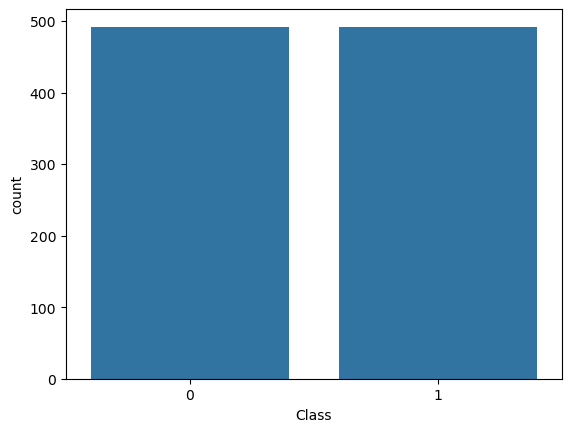

In [98]:
# Create a count plot to visualize the distribution of the 'Class' variable in the downsampled dataset
sns.countplot(x='Class', data=downsampled_df)


📌 Now that our dataset is balanced, we can move on to the next section: **handling outliers**.  
How should we approach outliers? Should we simply delete them? Let's explore.


<Axes: xlabel='V11', ylabel='V17'>

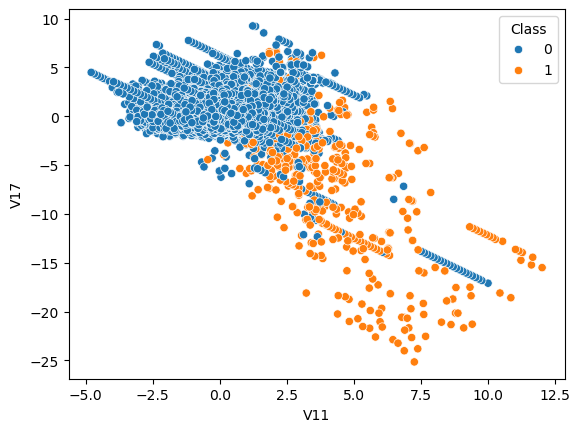

In [99]:
# Create a scatterplot to visualize the relationship between features V11 and V17
# Color-code the points by 'Class' to distinguish fraudulent vs. non-fraudulent transactions
sns.scatterplot(x='V11', y='V17', hue='Class', data=df2)


📌 **Outliers** are data points that significantly deviate from the average of a variable.  
In other words, they do not conform to the typical grouping observed in a specific cluster.

Did you notice something interesting in this plot?

- The **blue dots** represent normal transactions, tightly clustered with very few outliers.
- The **orange dots** represent fraudulent transactions, which do **not form a distinct cluster**, making outlier detection challenging.

Is this pattern consistent across all variables or just in this example?  
**Let's investigate further.**


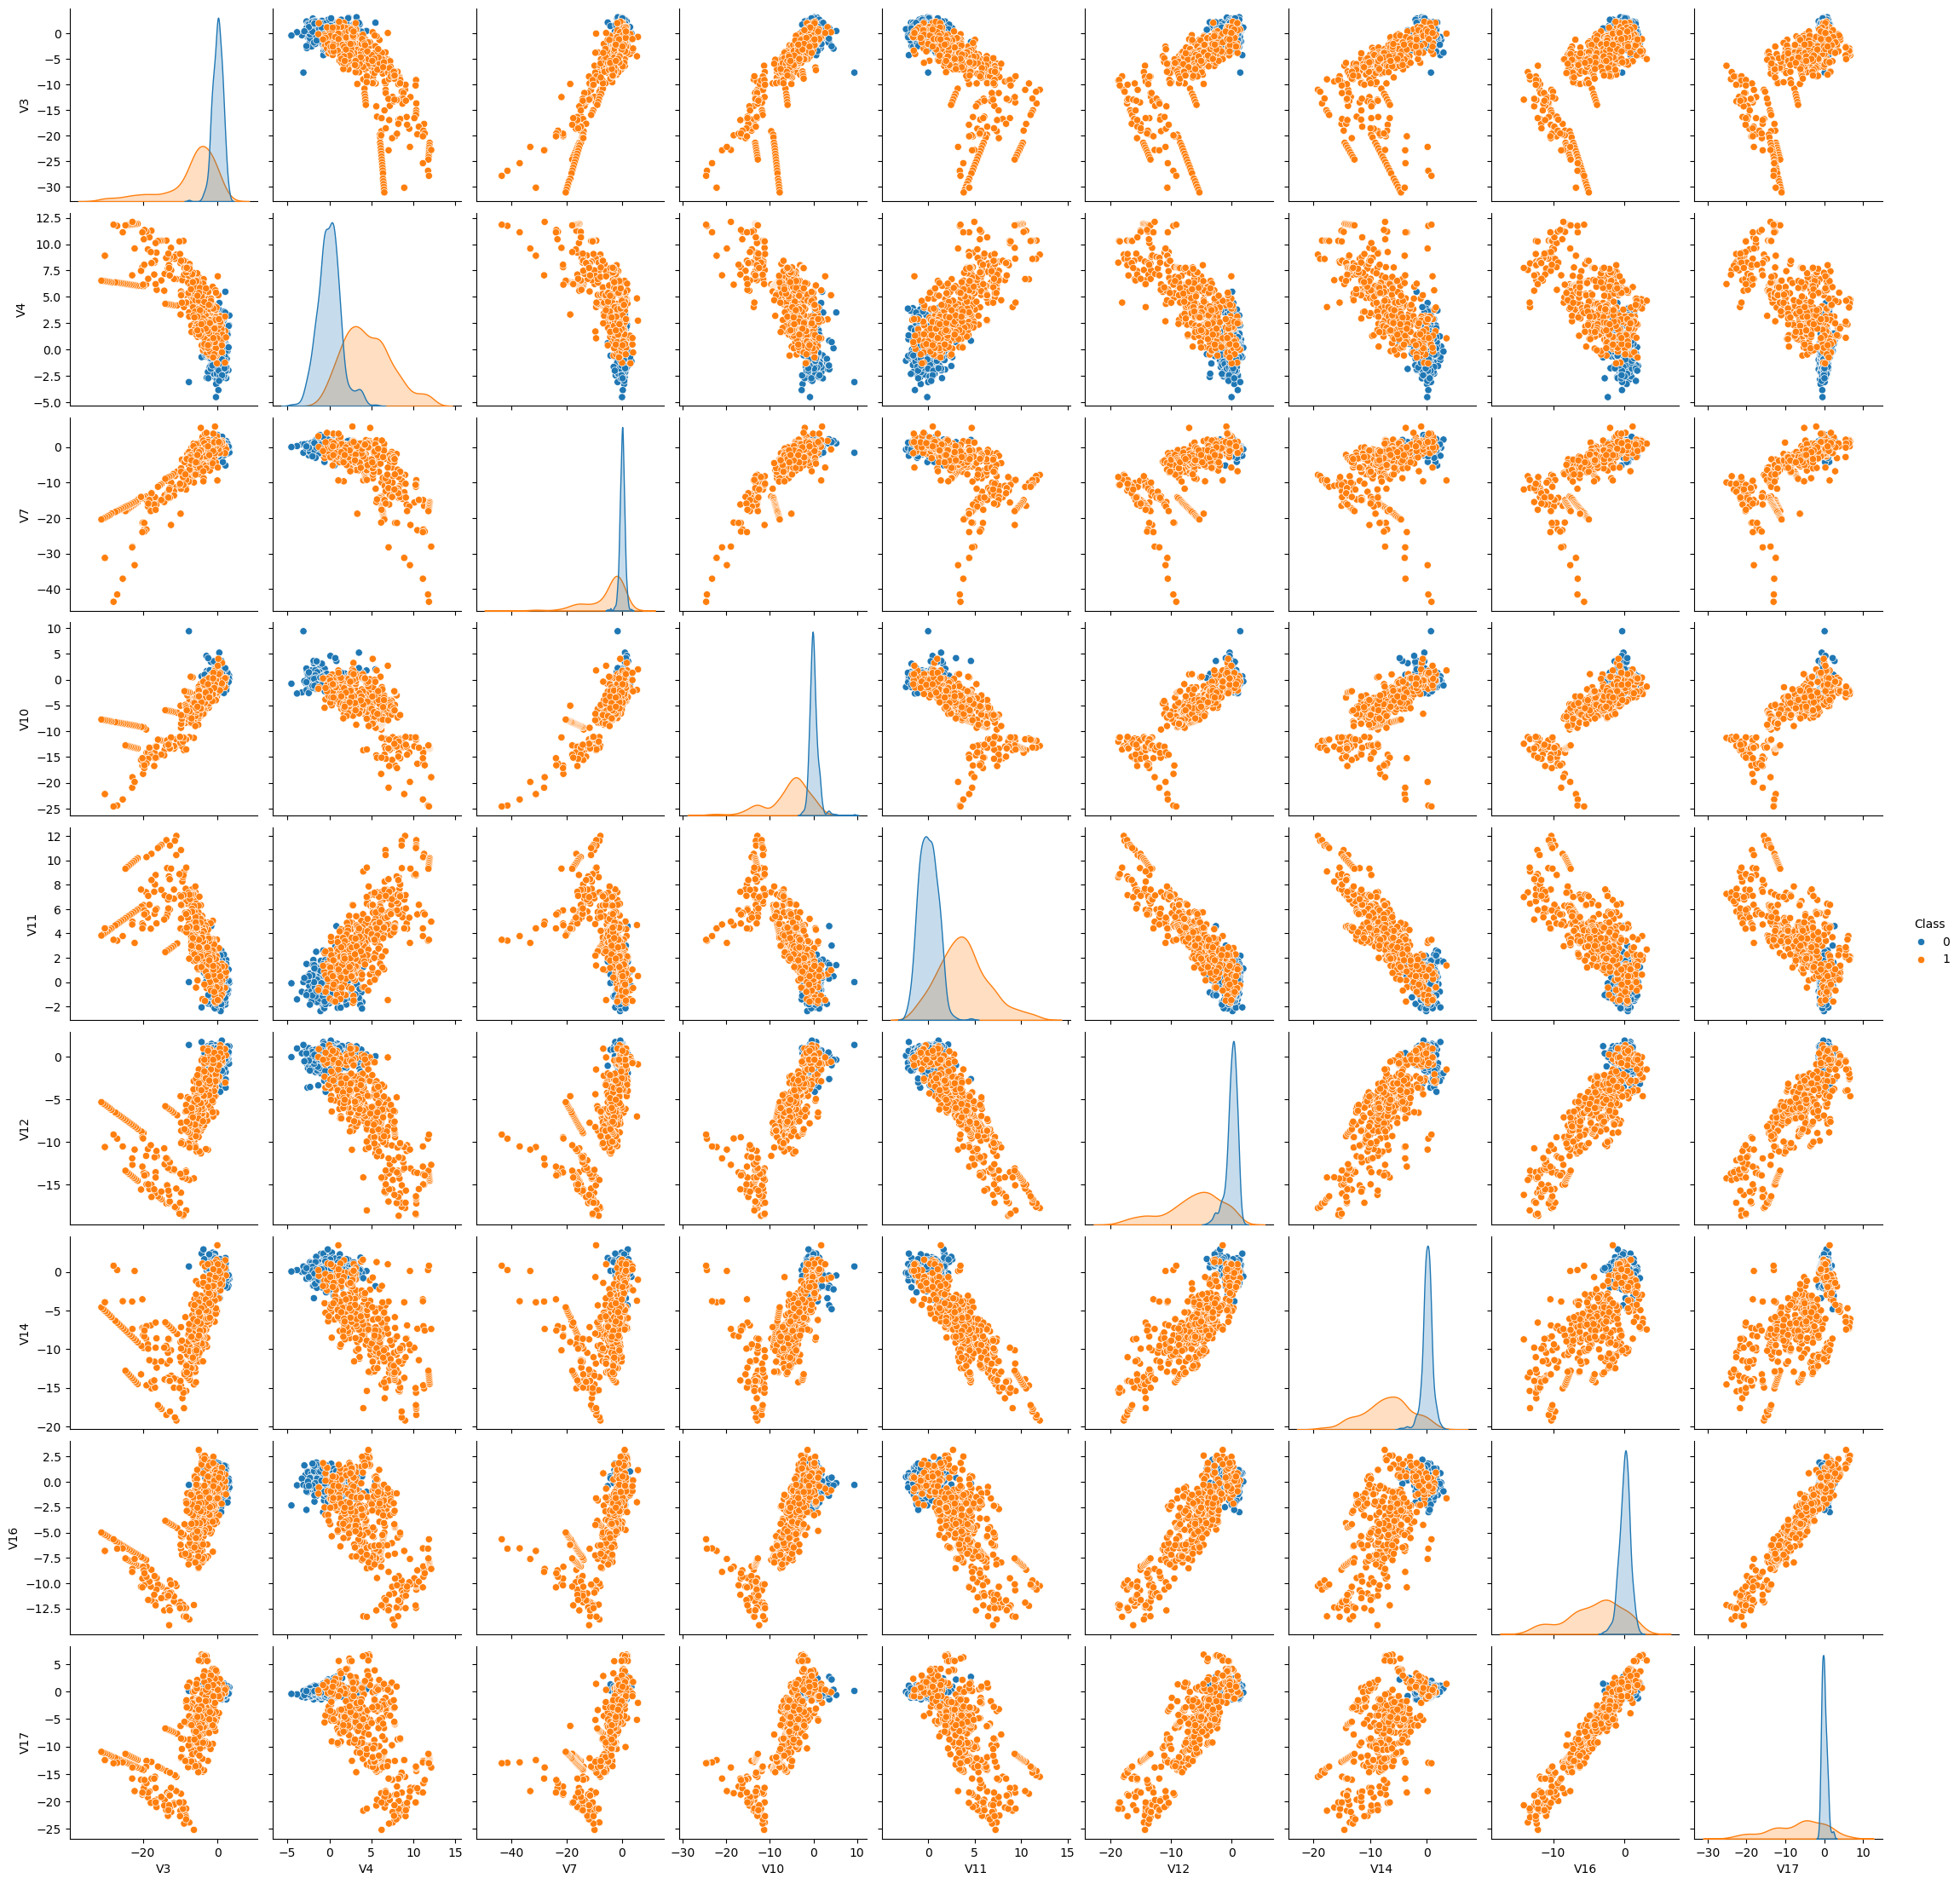

In [100]:
# Import the warnings module to manage warning messages
import warnings

# Suppress all warning messages to keep the output clean and focused
warnings.filterwarnings('ignore')

# Create pairwise scatterplots for all feature combinations in the downsampled dataset
# Color-code the points by 'class' to visualize how fraudulent and non-fraudulent transactions differ across feature pairs
sns.pairplot(downsampled_df, hue='Class')


📌 As you may have observed in this **pairplot**, normal transactions form a **distinct cluster** across all variables,  
whereas fraudulent transactions do **not exhibit a specific cluster**.  

This makes **outlier detection extremely challenging**.  
Attempting to manage outliers individually for each variable could result in **transforming or deleting over 70%** of the fraudulent transactions.


⚠️ **Fraudulent transactions do not exhibit clustering behavior and do not conform to a normal distribution**,  
making outlier identification challenging.

---

- This phenomenon arises because **fraud does not adhere to a typical distribution pattern**;  
  in other words, fraudulent activities vary widely and do not consistently follow specific patterns.

- **Fraudsters employ diverse methods** that evolve over time.  
  It's important to note that simply obtaining credit card details and full names is insufficient for completing transactions.  
  Fraudsters often use additional techniques such as **SIM swapping** to bypass payment verification processes.

- Due to these factors, datasets containing fraudulent transactions **lack distinct clustering** and do not follow a normal distribution.

---

✅ **For these reasons, no records will be deleted from fraudulent transactions.**  
Additionally, it's important to consider that **fraudulent transactions are rare**, making each record valuable.

📌 **Note:** Outliers can still be removed from **normal transactions** (non-fraudulent transactions).


In [101]:
# Export the filtered DataFrame (df2) to a CSV file
# Save it to the specified path without including the index column
df2.to_csv("../data/processed/processed_data.csv", index=False)


## **6.Proper Data Spliting**

In [102]:
# Load the processed dataset from the specified CSV file path
# Make sure the path is correct and accessible from your working directory
df2 = pd.read_csv("../data/processed/processed_data.csv")


In [103]:
# Import the train_test_split function to split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import resample for manual sampling operations like bootstrapping or downsampling
from sklearn.utils import resample

# Import classification_report and confusion_matrix to evaluate model performance
from sklearn.metrics import classification_report, confusion_matrix


In [104]:
# Separate the feature matrix (X) by dropping the target column 'Class'
X = df2.drop(columns='Class')

# Extract the target vector (y) containing the 'Class' labels
y = df2['Class']


In [105]:
# Step 1: Split the original data into training and testing sets with stratification

# Use stratified sampling to preserve class distribution in both training and test sets
# Set test_size=0.2 to allocate 20% of the data for testing
# Set random_state=42 for reproducibility
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [106]:
# Step 2: Downsample only the training data to ensure no data leakage

# Create a copy of the original training features
train_data = X_train_orig.copy()

# Attach the correct training labels to the training feature set
train_data['Class'] = y_train_orig


In [107]:
# Separate the majority and minority classes in the training data

# Extract all rows where 'Class' is 0 — typically representing non-fraudulent transactions
majority_class = train_data[train_data['Class'] == 0]  # Assuming 0 is the majority class

# Extract all rows where 'Class' is 1 — typically representing fraudulent transactions
minority_class = train_data[train_data['Class'] == 1]  # Assuming 1 is the minority class


In [108]:
# Downsample the majority class to match the number of minority class samples
majority_downsampled = resample(
    majority_class,              # Data to downsample (majority class)
    replace=False,               # Sample without replacement
    n_samples=len(minority_class),  # Match the number of minority samples
    random_state=42              # Ensure reproducibility
)


In [109]:
# Combine the downsampled majority class with the minority class
# This creates a balanced training dataset with equal representation of both classes
downsampled_train_data = pd.concat([majority_downsampled, minority_class])


In [110]:
# Step 3: Prepare the downsampled training set and the original test set

# Extract the feature matrix from the balanced training data by dropping the target column 'Class'
X_train_downsampled = downsampled_train_data.drop(columns='Class')

# Extract the target vector containing the 'Class' labels from the balanced training data
y_train_downsampled = downsampled_train_data['Class']


⚠️ **To properly split the data, we need to follow these rules:**

---

### ✅ Use a stratified split  
Since the data is highly imbalanced, a random split might result in a training or test set with **no fraud transactions**.  
Fraud transactions represent only a fraction of the dataset, so the risk of ending up with a dataset without fraud is high.  
A **stratified split** ensures that this imbalance is maintained in both the training and test sets, preventing this issue.

---

### ✅ Downsample the training data  
As previously explained, this is important to **avoid bias** and ensure that the model learns effectively.

---

### ✅ Ensure the distribution of the test data matches the original data  
This is crucial for **evaluating the model's performance in real-world scenarios**.

---

### ✅ Avoid data leakage  
Ensure that there is **no overlap between the final training and test datasets** to prevent information from the test set influencing the training process.


## **7. Quick Test Using Lazy Predict**

In [111]:
!pip install lazypredict


In [112]:
# Import LazyClassifier from the lazypredict library's supervised module
# This tool automatically trains and compares multiple classification models with minimal setup
from lazypredict.Supervised import LazyClassifier

# Step 4: Initialize LazyClassifier and fit the model

# Create an instance of LazyClassifier with a fixed random_state for reproducibility
clf = LazyClassifier(random_state=42)


In [113]:
# Fit the models using the downsampled training data and test on the original test set

# Automatically train and evaluate multiple classification models using LazyClassifier
# The models are trained on the balanced training set and evaluated on the original test set
models, predictions = clf.fit(X_train_downsampled, X_test_orig, y_train_downsampled, y_test_orig)

# Display the performance of the models

# Show a summary table with metrics like accuracy, F1-score, and training time for each model
models


  0%|          | 0/32 [00:00<?, ?it/s]

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LogisticRegression,0.97,0.95,0.95,0.99,0.09
LinearSVC,0.97,0.95,0.95,0.98,0.08
SVC,0.99,0.95,0.95,0.99,1.09
SGDClassifier,0.99,0.95,0.95,0.99,0.10
CalibratedClassifierCV,0.98,0.95,0.95,0.99,0.20
PassiveAggressiveClassifier,0.98,0.94,0.94,0.99,0.10
ExtraTreesClassifier,0.97,0.94,0.94,0.98,0.91
KNeighborsClassifier,0.98,0.94,0.94,0.99,0.64
RandomForestClassifier,0.96,0.94,0.94,0.98,0.94


⚠️ **Avoiding the Big Trap**

Let's remember that our **test data is highly imbalanced**.  
Relying solely on **accuracy** as the main metric for choosing our model is a significant mistake.

---

✅ The proper approach is to find a model that balances:
- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**

---

📌 However, since detecting **normal transactions** is not challenging for machine learning models,  
we will focus on the **F1 score for fraudulent transactions** (`Class == 1`).


In [114]:
# Import Bernoulli Naive Bayes classifier — suitable for binary/boolean feature sets
from sklearn.naive_bayes import BernoulliNB

# Import Nu-Support Vector Classifier — an alternative SVM formulation with a controllable number of support vectors
from sklearn.svm import NuSVC

# Import Nearest Centroid classifier — a simple and fast model that classifies based on proximity to class centroids
from sklearn.neighbors import NearestCentroid

# Import F1 score metric — balances precision and recall, especially useful for imbalanced classification tasks
from sklearn.metrics import f1_score


In [115]:
# Initialize the models

# Create a dictionary of classifiers to evaluate manually
models = {
    # Bernoulli Naive Bayes — suitable for binary features, fast and interpretable
    'BernoulliNB' : BernoulliNB(),

    # Nu-Support Vector Classifier — allows control over the number of support vectors
    # Set probability=True to enable probability estimates (required for some metrics or plots)
    'NuSVC'        : NuSVC(probability=True),

    # Nearest Centroid — classifies based on proximity to class centroids, simple and efficient
    'NearestCentroid' : NearestCentroid()
}


In [116]:
# Fit models and calculate F1 scores

# Initialize an empty dictionary to store F1 scores for each model
f1_scores = {}

# Loop through each model in the dictionary
for name, model in models.items():
    # Fit the model using the downsampled training data
    model.fit(X_train_downsampled, y_train_downsampled)

    # Make predictions on the original (imbalanced) test set
    y_pred = model.predict(X_test_orig)

    # Calculate the F1 score for the positive class (fraudulent transactions)
    f1_scores[name] = f1_score(y_test_orig, y_pred, pos_label=1)


In [118]:
# Display the F1 scores for each model

# Print a header for clarity
print("F1 Scores for class==1:")

# Loop through the dictionary and print each model's F1 score formatted to 4 decimal places
for name, score in f1_scores.items():
    print(f"{name}: {score:.4f}")


F1 Scores for class==1:
BernoulliNB: 0.0994
NuSVC: 0.5950
NearestCentroid: 0.8144


📌 **Model Selection Based on F1 Score**

We initially chose the three models with the highest accuracy.  
However, to better evaluate their performance on detecting fraudulent transactions (`Class == 1`),  
we compared their **F1 scores** and obtained the following results:

---

### 🎯 F1 Scores for Class == 1
- **BernoulliNB**: 0.0994  
- **NuSVC**: 0.5950  
- **NearestCentroid**: 0.8144  

---

🏆 **Our winner is NearestCentroid**, so let's proceed to the next section.


## **8. Final Model**

In [120]:
# Import the Nearest Centroid classifier — our selected winner for fraud detection
from sklearn.neighbors import NearestCentroid

# Import classification report — provides precision, recall, F1 score, and support for each class
from sklearn.metrics import classification_report, confusion_matrix

# Import seaborn — a statistical data visualization library for creating attractive plots
import seaborn as sns

# Import matplotlib — the foundational plotting library used by seaborn and others
import matplotlib.pyplot as plt


In [121]:
# Initialize the NearestCentroid model

# Create an instance of NearestCentroid and assign it a custom name for clarity and fun
# This model will classify transactions based on proximity to class centroids
FRAUDFIGHTER = NearestCentroid()


In [122]:
# Fit the model on the downsampled training data

# Train the NearestCentroid classifier using the balanced dataset
# This step computes the centroid of each class and prepares the model for prediction
FRAUDFIGHTER.fit(X_train_downsampled, y_train_downsampled)


,metric,'euclidean'
,shrink_threshold,None
,priors,'uniform'


In [123]:
# Predict on the original test data

# Use the trained NearestCentroid model to classify transactions in the original (imbalanced) test set
# This will generate predicted labels for each test sample
y_pred = FRAUDFIGHTER.predict(X_test_orig)


In [125]:
# Generate classification report

# Create a detailed performance summary including precision, recall, F1 score, and support for each class
report = classification_report(y_test_orig, y_pred)

# Print the classification report to the console
print("Classification Report: \n", report)


Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [126]:
# Generate confusion matrix

# Compare predicted labels to true labels from the original test set
conf_matrix = confusion_matrix(y_test_orig, y_pred)


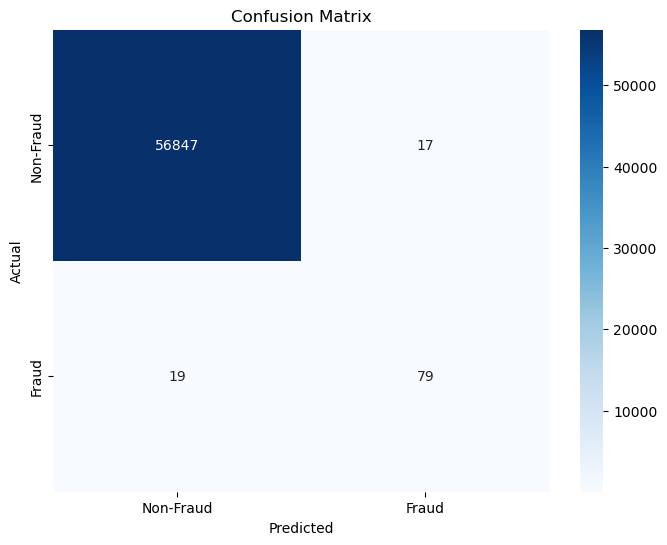

In [128]:
# Plot the confusion matrix

# Set the figure size for better readability
plt.figure(figsize=(8,6))

# Create a heatmap using seaborn to visualize the confusion matrix
# 'annot=True' displays the numeric values in each cell
# 'fmt="d"' formats the annotations as integers
# 'cmap="Blues"' sets the color scheme
# 'xticklabels' and 'yticklabels' label the axes with class names
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Actual'
plt.ylabel('Actual')

# Add a title to the plot
plt.title('Confusion Matrix')

# Display the plot
plt.show()


## **Logistic Regression**

In [130]:
# Import Logistic Regression — a widely used linear model for binary classification
# It estimates probabilities using a logistic function and is interpretable and efficient
from sklearn.linear_model import LogisticRegression

# Initialize the LogisticRegression model
log_reg = LogisticRegression()




In [132]:
# Fit the model on the downsampled training data

# Train the Logistic Regression model using the balanced training set
# This step learns the relationship between features and the target class
log_reg.fit(X_train_downsampled, y_train_downsampled)

# Predict on the original test data

# Use the trained model to classify transactions in the original (imbalanced) test set
# This generates predicted labels for each test sample
y_pred = log_reg.predict(X_test_orig)


In [135]:
# Generate classification report

# Create a detailed summary of model performance on the original test set
# Includes precision, recall, F1 score, and support for each class
report = classification_report(y_test_orig, y_pred)

# Print the classification report to the console
print("Classification Report: \n", report)


Classification Report: 
               precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.93      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.95      0.53     56962
weighted avg       1.00      0.96      0.98     56962



In [137]:
# Generate confusion matrix

# Compare predicted labels to true labels from the original test set
# This matrix summarizes correct and incorrect predictions for each class
conf_matrix = confusion_matrix(y_test_orig, y_pred)


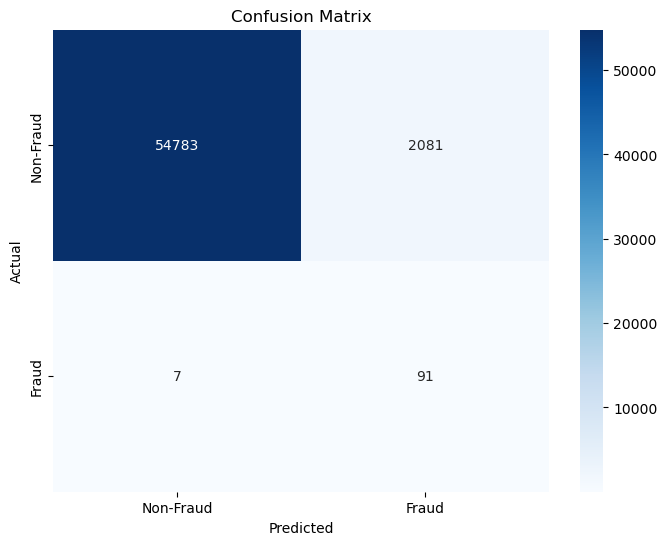

In [139]:
# Plot the confusion matrix

# Set the figure size for better readability
plt.figure(figsize=(8,6))

# Create a heatmap to visualize the confusion matrix
# 'annot=True' displays the numeric values in each cell
# 'fmt="d"' formats the annotations as integers
# 'cmap="Blues"' sets the color scheme
# 'xticklabels' and 'yticklabels' label the axes with class names
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])

# Label the x-axis as 'Predicted'
plt.xlabel('Predicted')

# Label the y-axis as 'Actual'
plt.ylabel('Actual')

# Add a title to the plot
plt.title('Confusion Matrix')

# Display the plot
plt.show()


In [140]:
# Save the model to a pickle file in the 'models' directory

# Define the directory where the model will be saved
model_directory = '../models'

# Define the filename for the saved Logistic Regression model
model_filename = 'logistic_regression_model.pkl'


In [141]:
# Create the directory if it doesn't exist

# Check if the target directory for saving the model exists
# If not, create it to ensure the save operation doesn't fail
if not os.path.exists(model_directory):
    os.mkdir(model_directory)

# Construct the full file path by joining directory and filename
model_filepath = os.path.join(model_directory, model_filename)

# Open the file in write-binary mode and save the trained model using pickle
with open(model_filepath, 'wb') as file:
    pickle.dump(log_reg, file)

# Confirm that the model has been successfully saved
print(f"Model saved to {model_filepath}")


Model saved to ../models\logistic_regression_model.pkl


## **9. Minimizing False Negatives: A Crucial Step**

⚠️ **False Negatives in Credit Card Fraud Detection**

In credit card fraud detection, **minimizing false negatives** — fraudulent transactions classified as non-fraudulent — is crucial and often **as important as accuracy**, if not more so.

Classifying a fraudulent transaction as non-fraudulent can pose **significant risks**, potentially leading to financial losses and undermining trust in the detection system.

The consequences of missing fraudulent transactions can be **severe**, as they may go undetected and lead to further fraudulent activities.

👉 Therefore, achieving a **balance between high accuracy and low false negatives** is essential for building robust and trustworthy fraud detection systems.


⚠️ **Example: The Cost of a False Negative in Fraud Detection**

Suppose a bank earns **$1 profit per transaction**, whether normal or fraudulent.

There are **100 transactions**:
- 99 are normal
- 1 is fraudulent

---

### 💰 Profit from Normal Transactions:
- \( 99 \times \$1 = \$99 \)

---

### 🚨 The Fraudulent Transaction:
- Amount: **$100**
- If misclassified as normal:
  - Bank earns: **$1**
  - Actual loss: **$100**

---

### 🧮 Final Calculation:
- Total profit from normal transactions: **$99**
- Loss from misclassified fraud: **$100**
- **Net profit**: \( \$99 - \$100 = \$0 \)

---

🔍 **Conclusion**:  
Misclassifying just **one fraudulent transaction** can wipe out all profits from 99 legitimate ones.  
This highlights the **critical importance of minimizing false negatives** in fraud detection systems.


📌 **False Negatives and Dataset Limitations**

For this dataset, we **didn’t find a way to reduce false negatives**.  
However, we included the above disclaimers to make this notebook **useful across different datasets**.

We also explained **why false negatives are a significant issue** in fraud detection —  
highlighting the risks, consequences, and importance of minimizing them in real-world applications.


## **10. Features Importance**

In [143]:
# Import permutation importance — a model-agnostic method to assess feature impact
from sklearn.inspection import permutation_importance

# Compute permutation importance

# Evaluate how each feature affects the model's F1 score by randomly shuffling its values
# 'n_repeats=10' ensures stability by averaging over multiple shuffles
# 'random_state=42' guarantees reproducibility
# 'scoring="f1"' focuses the importance calculation on fraud detection performance
result = permutation_importance(model, X_test_orig, y_test_orig, 
                                n_repeats=10, random_state=42, scoring='f1')


In [144]:
# Get mean and standard deviation of importance values

# Extract the average importance score for each feature across all permutations
importance = result.importances_mean

# Extract the standard deviation to understand variability in importance estimates
std = result.importances_std


In [146]:
# Create a DataFrame for easy plotting

# Combine feature names, importance scores, and standard deviations into a single DataFrame
# Sort the features by descending importance to highlight the most influential ones
importance_df = pd.DataFrame({
    'Feature': X_test_orig.columns, 
    'Importance': importance,
    'Std dev': std 
}).sort_values(by='Importance', ascending=False)


In [149]:
# Print the DataFrame

# Display the sorted feature importance scores along with their standard deviations
# This helps identify which features most influence the model's F1 score
print("Feature Importances: \n", importance_df)


Feature Importances: 
   Feature  Importance  Std dev
0      V3        0.12     0.01
6     V14        0.11     0.01
8     V17        0.09     0.01
5     V12        0.08     0.01
3     V10        0.06     0.01
2      V7        0.06     0.01
1      V4        0.04     0.01
7     V16        0.04     0.00
4     V11        0.03     0.00


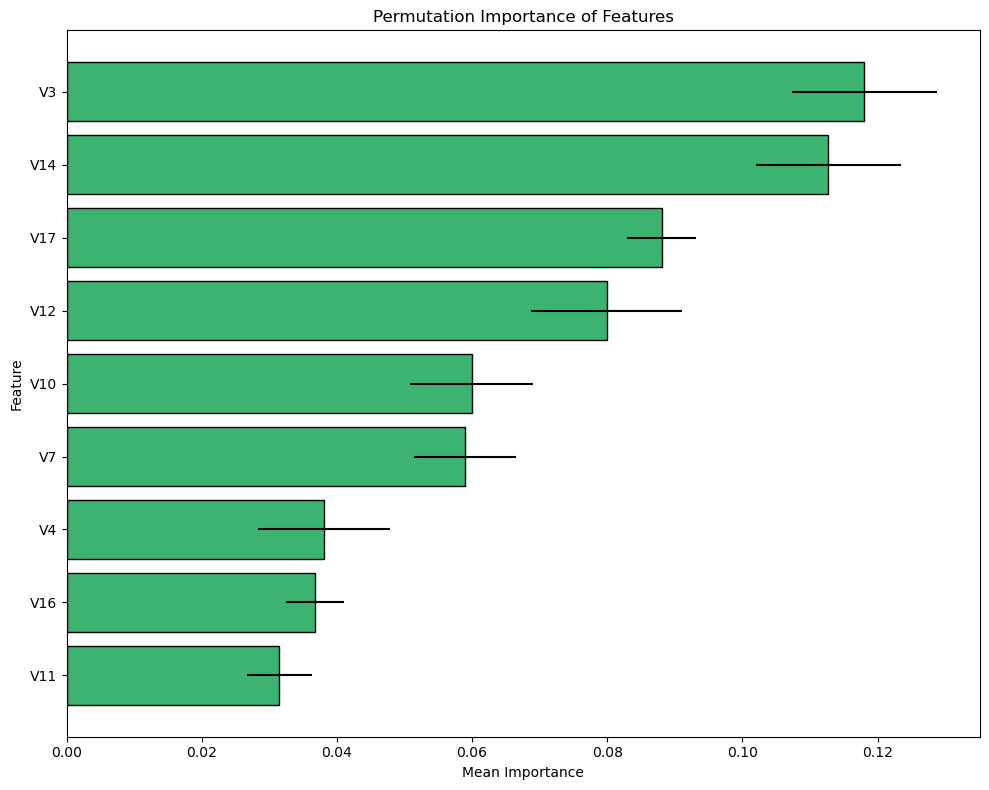

In [155]:
# Plot feature importances using Matplotlib for error bars

plt.figure(figsize=(10, 8))

# Extract values
features = importance_df['Feature']
importances = importance_df['Importance']
errors = importance_df['Std Dev']

# Create horizontal bar chart with error bars
plt.barh(features, importances, xerr=errors, color='mediumseagreen', edgecolor='black')

# Invert y-axis so most important features appear at the top
plt.gca().invert_yaxis()

# Label axes and title
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.title('Permutation Importance of Features')

plt.tight_layout()
plt.show()


📌 **Top Contributing Features**

We assessed feature importance and found that `V3`, `V14`, and `V17` are the **top contributors** to our model’s performance.


## 11. Conclusions

### ✅ Effective Model Development  
Through meticulous data preprocessing, feature selection, and model optimization steps, we've developed a robust fraud detection model.

### ⚖️ Importance of Imbalance Handling  
Addressing the imbalance in the dataset was critical.  
Downsampling the majority class improved model performance by ensuring balanced representation of fraudulent and non-fraudulent transactions.

### 📊 Model Performance  
Our final model, **FRAUDFIGHTER**, achieved an impressive **accuracy of 99%** with minimal false negatives and false positives.  
This underscores its capability to accurately detect fraudulent transactions.

### 🌍 Real-world Application  
The methodologies and techniques applied here are crucial for real-world applications,  
where the cost of misclassifying fraudulent transactions can be substantial — both financially and in terms of trust and customer satisfaction.

### 🚀 Future Directions  
Further enhancements could involve:
- Exploring advanced feature engineering techniques  
- Integrating additional data sources  
- Deploying the model in a real-time environment  
to continuously improve fraud detection capabilities.


📌 👋 **Thank You!**

Thank you for reading this notebook!  
If you found this content useful, please consider giving it an **upvote** — your support is greatly appreciated! 🌟
